<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/12_robust_student_t_and_loo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 12 — Robust likelihoods and PSIS-LOO

Compare Gaussian and Student-t likelihoods, and varying-intercept versus varying-intercept-and-slope structure, using leave-one-out predictive checks.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.

#### Format colors

In [4]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

#### plot_population

Plot any variable against days using plot_lm. Use the standard colors and legend above.

In [5]:

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same as plot_population but for the participants. 

In [6]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

In [7]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 12.1 Difficult-to-predict observations

Do Gaussian hierarchical models contain observations that are difficult to predict when they are left out of the fit?

We fit four standalone models here so the notebook does not depend on state from earlier notebooks: Gaussian and Student-t likelihoods, each with varying intercepts only or varying intercepts plus slopes. All four share the same mean-structure priors as notebooks 4–5; the Student-t models add a degrees-of-freedom prior matching Bambi's own default, $\nu\sim\text{Gamma}(2, 0.1)$.

In [8]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

def build_model(family, varying_slope):
    """Gaussian or Student-t likelihood, with or without varying slopes."""
    with pm.Model(coords=coords) as model:
        days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
        pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

        intercept = pm.Normal("intercept", mu=250, sigma=100)
        slope = pm.Normal("slope", mu=0, sigma=20)
        sigma = pm.Exponential("sigma", lam=0.04)

        participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=0.04)
        participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
        participant_intercept = pm.Deterministic(
            "participant_intercept",
            participant_intercept_sd * participant_intercept_z,
            dims="participant",
        )

        mu = intercept + slope * days + participant_intercept[pidx]
        if varying_slope:
            participant_slope_sd = pm.Exponential("participant_slope_sd", lam=0.10)
            participant_slope_z = pm.Normal("participant_slope_z", 0, 1, dims="participant")
            participant_slope = pm.Deterministic(
                "participant_slope",
                participant_slope_sd * participant_slope_z,
                dims="participant",
            )
            mu = mu + participant_slope[pidx] * days
        mu = pm.Deterministic("mu", mu, dims="obs_id")

        if family == "gaussian":
            pm.Normal(
                "Reaction", mu=mu, sigma=sigma,
                observed=sleep["Reaction"].to_numpy(), dims="obs_id",
            )
        else:
            nu = pm.Gamma("nu", alpha=2, beta=0.1)
            pm.StudentT(
                "Reaction", nu=nu, mu=mu, sigma=sigma,
                observed=sleep["Reaction"].to_numpy(), dims="obs_id",
            )
    return model

models = {
    "gaussian_intercept": build_model("gaussian", varying_slope=False),
    "gaussian_slope": build_model("gaussian", varying_slope=True),
    "student_t_intercept": build_model("student_t", varying_slope=False),
    "student_t_slope": build_model("student_t", varying_slope=True),
}

In [9]:
idatas = {}
for name, model in models.items():
    print("\n---", name, "---")
    with model:
        idatas[name] = pm.sample(
            draws=1000, tune=1500, chains=4, target_accept=0.95, random_seed=RANDOM_SEED
        )
        print("Divergences:", int(idatas[name]["sample_stats"]["diverging"].sum().item()))
        display(azs.summary(
            idatas[name], var_names=["intercept", "slope", "sigma"],
            kind="diagnostics", round_to=2,
        ))
        pm.sample_posterior_predictive(
            idatas[name], var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
        )
        pm.compute_log_likelihood(idatas[name])


--- gaussian_intercept ---


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, sigma, participant_intercept_sd, participant_intercept_z]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...

Divergences: 0


,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,988.67,1451.96,1.0,0.28,0.17
slope,1174.89,1528.34,1.0,0.06,0.05
sigma,2801.26,3271.17,1.0,0.03,0.02


Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

These intervals use PSIS-LOO weighting rather than the ordinary full-data posterior predictive distribution. Large discrepancies help identify observations for which the fitted model depends strongly on seeing that observation.

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\arviz_stats\loo\loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\arviz_stats\loo\loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\arviz_stats\loo\loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


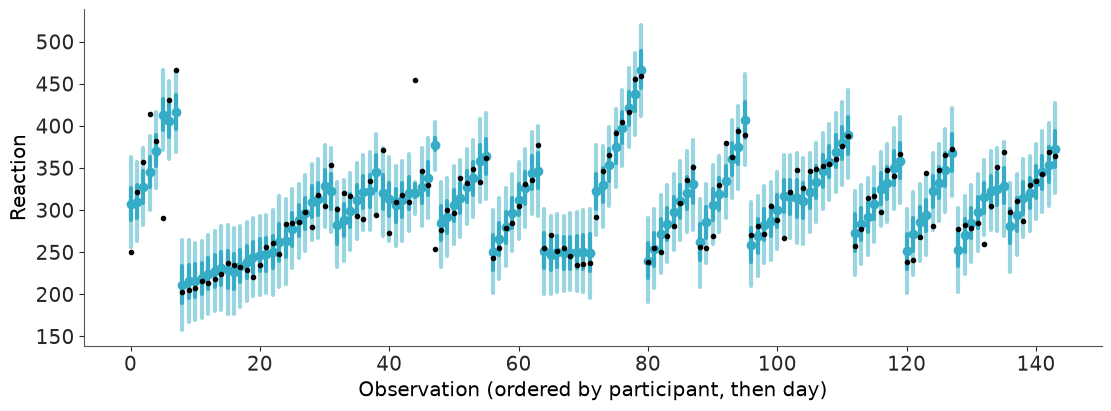

In [10]:
pc = azp.plot_loo_interval(
    idatas["gaussian_slope"], var_names=["Reaction"],
    point_estimate="mean", ci_probs=(0.50, 0.90), ci_kind="hdi",
    figure_kwargs={"figsize": (11, 4)},
)
pc.viz["figure"].item().axes[0].set_xlabel("Observation (ordered by participant, then day)")
plt.show()

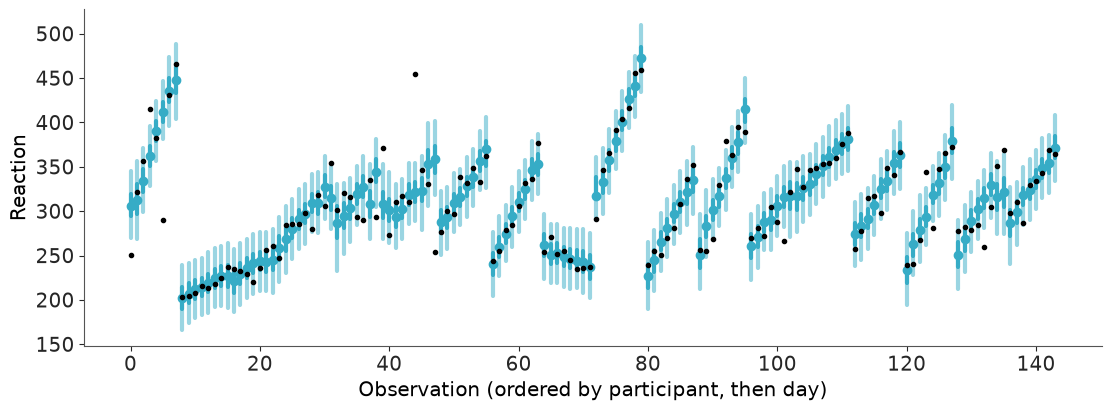

In [11]:
pc = azp.plot_loo_interval(
    idatas["student_t_slope"], var_names=["Reaction"],
    point_estimate="mean", ci_probs=(0.50, 0.90), ci_kind="hdi",
    figure_kwargs={"figsize": (11, 4)},
)
pc.viz["figure"].item().axes[0].set_xlabel("Observation (ordered by participant, then day)")
plt.show()

## 12.2 Robust predictive calibration

Does replacing the Gaussian likelihood with a Student-t likelihood improve leave-one-out calibration?

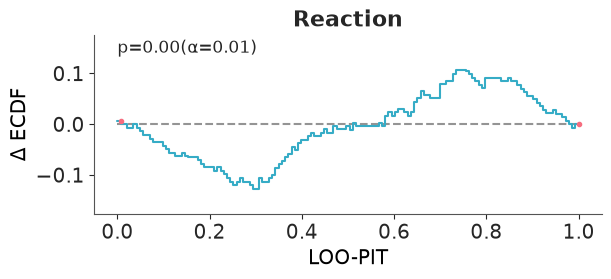

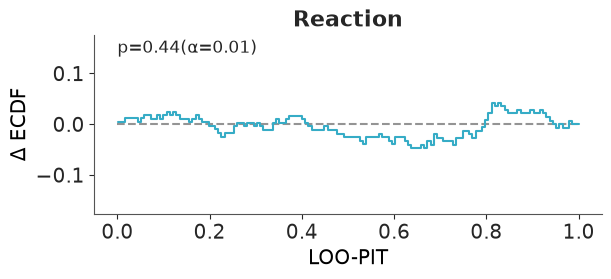

In [12]:
azp.plot_loo_pit(idatas["gaussian_slope"], var_names=["Reaction"]);
azp.plot_loo_pit(idatas["student_t_slope"], var_names=["Reaction"]);

## 12.3 Predictive comparison

What do PSIS-LOO diagnostics and ELPD differences say about likelihood choice and the value of varying slopes?

In [13]:
loos = {
    name: azs.loo(idata, var_name="Reaction", pointwise=True)
    for name, idata in idatas.items()
}

for name, loo in loos.items():
    print(name, "ELPD:", round(float(loo.elpd), 2), "SE:", round(float(loo.se), 2),
          "max Pareto k:", round(float(loo.pareto_k.max()), 2))

comparison = azs.compare(loos, method="stacking", round_to="none")
comparison

D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\arviz_stats\loo\loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\arviz_stats\loo\loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


gaussian_intercept ELPD: -707.35 SE: 14.84 max Pareto k: 0.74
gaussian_slope ELPD: -691.7 SE: 22.18 max Pareto k: 1.27
student_t_intercept ELPD: -698.44 SE: 12.23 max Pareto k: 0.68
student_t_slope ELPD: -652.59 SE: 14.06 max Pareto k: 0.57


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
student_t_slope,0,0.000000,0.000000,NaN,,,43.596905,-652.590435,14.063970,1.000000e+00
gaussian_slope,1,-39.107137,13.280607,0.998384,,3 k̂ > 0.70,32.135887,-691.697571,22.182625,4.934941e-14
student_t_intercept,2,-45.847048,8.626453,1.000000,,,23.526948,-698.437482,12.234794,8.193723e-13
gaussian_intercept,3,-54.757867,9.657273,1.000000,,1 k̂ > 0.70,20.097052,-707.348301,14.840245,1.142725e-12


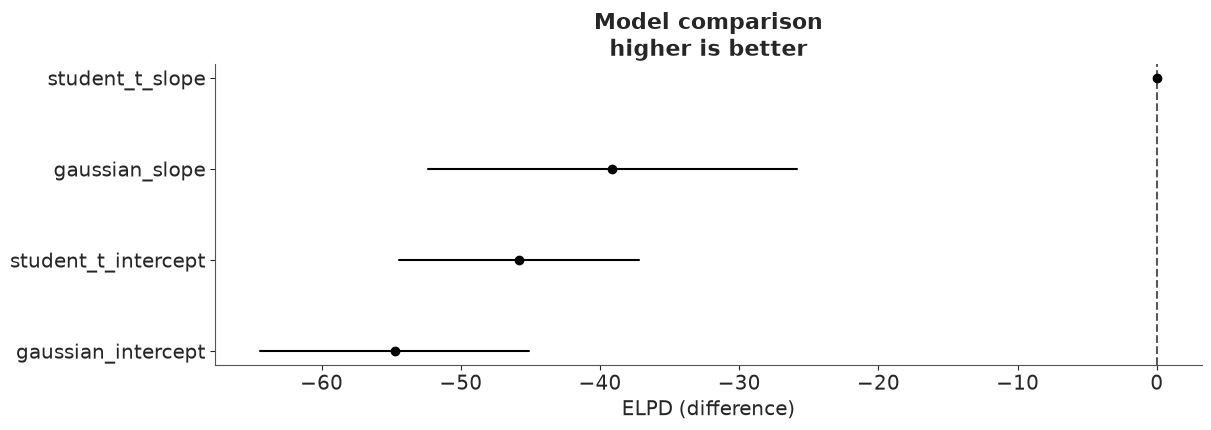

In [14]:
azp.plot_compare(comparison);

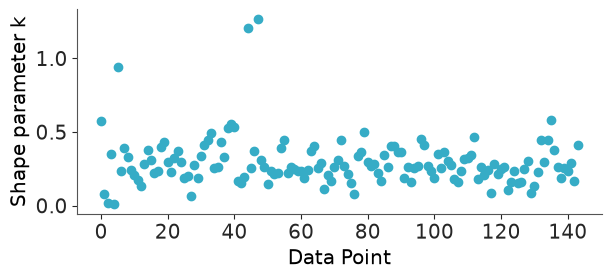

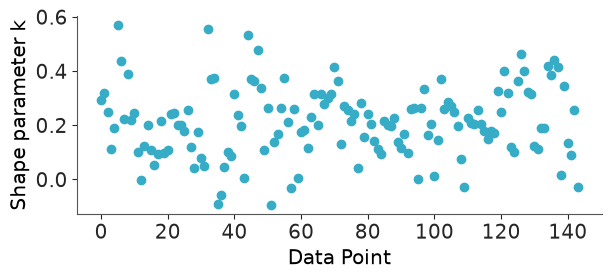

In [15]:
azp.plot_khat(loos["gaussian_slope"]);
azp.plot_khat(loos["student_t_slope"]);

## 12.4 Prediction target

What prediction problem does this leave-one-observation-out comparison actually answer?

This comparison asks about prediction of another observation from an **already observed participant**, because rows—not whole participants—are left out. It is not a validation of prediction for a completely new participant. Compare ELPD differences together with their uncertainty and Pareto-$k$ diagnostics; do not treat a numerical rank as proof that one scientific model is true.